# Statistical Anomaly Detection System

## Notebook 06: Model Evaluation and Dashboard Development

### Purpose

This notebook summarizes anomaly detection results and produces a dashboard for communicating findings.

### Objectives

- Evaluate anomaly detection outcomes
- Summarize risk distributions
- Visualize key findings
- Develop a portfolio-ready dashboard

### Expected Outcome

A comprehensive summary of the anomaly detection framework and a professional dashboard image.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest

import os

os.makedirs("images", exist_ok=True)

In [2]:
df = pd.read_csv(
    "Air Quality Data in India.csv",
    encoding="latin1",
    low_memory=False
)

pollutants = [
    "so2",
    "no2",
    "rspm",
    "spm"
]

air_quality = df[pollutants].copy()

for col in pollutants:
    air_quality[col] = (
        air_quality[col]
        .fillna(
            air_quality[col].median()
        )
    )

In [3]:
model = IsolationForest(
    contamination=0.01,
    random_state=42
)

model.fit(air_quality)

air_quality["anomaly"] = (
    model.predict(air_quality)
)

air_quality["anomaly_score"] = (
    model.decision_function(
        air_quality[pollutants]
    )
)

air_quality["risk_level"] = pd.qcut(
    air_quality["anomaly_score"],
    q=3,
    labels=[
        "High Risk",
        "Moderate Risk",
        "Low Risk"
    ]
)

In [4]:
risk_summary = (
    air_quality["risk_level"]
    .value_counts()
)

anomaly_summary = (
    air_quality["anomaly"]
    .value_counts()
)

print(risk_summary)

print("\n")

print(anomaly_summary)

risk_level
High Risk        9357
Low Risk         9357
Moderate Risk    9356
Name: count, dtype: int64


anomaly
 1    27789
-1      281
Name: count, dtype: int64


Portfolio Dashboard Image

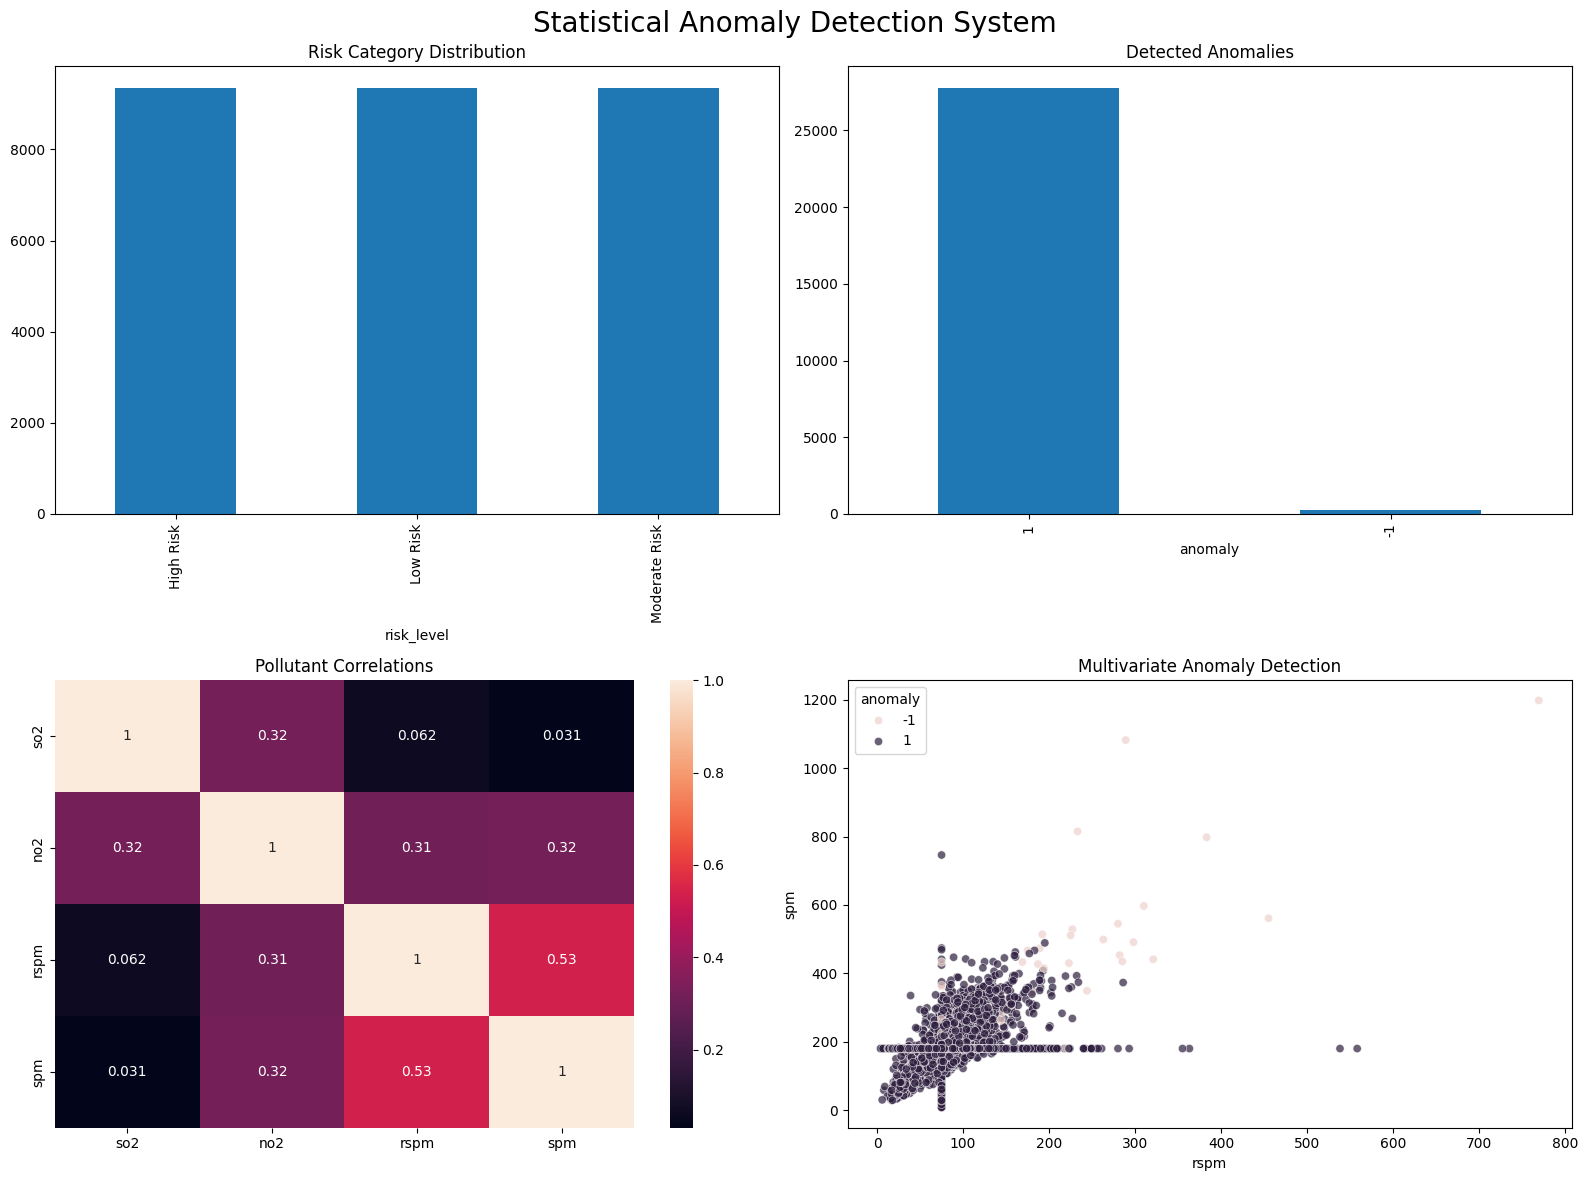

In [5]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(16,12)
)

# -------------------------
# Risk Distribution
# -------------------------

risk_summary.plot(
    kind="bar",
    ax=axes[0,0]
)

axes[0,0].set_title(
    "Risk Category Distribution"
)

# -------------------------
# Anomaly Counts
# -------------------------

anomaly_summary.plot(
    kind="bar",
    ax=axes[0,1]
)

axes[0,1].set_title(
    "Detected Anomalies"
)

# -------------------------
# Correlation Heatmap
# -------------------------

sns.heatmap(
    air_quality[pollutants].corr(),
    annot=True,
    ax=axes[1,0]
)

axes[1,0].set_title(
    "Pollutant Correlations"
)

# -------------------------
# Scatter Plot
# -------------------------

sample_data = (
    air_quality.sample(
        5000,
        random_state=42
    )
)

sns.scatterplot(
    data=sample_data,
    x="rspm",
    y="spm",
    hue="anomaly",
    alpha=0.7,
    ax=axes[1,1]
)

axes[1,1].set_title(
    "Multivariate Anomaly Detection"
)

plt.suptitle(
    "Statistical Anomaly Detection System",
    fontsize=20
)

plt.tight_layout()

plt.savefig(
    "images/project_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()